# *Imports and file reading*

In [59]:

import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt


#Neccesary imports to run visualizations and pandas analysis 

In [60]:
import csv
with open("Data/battle_data.csv", "r") as f:
    reader = csv.reader(f)
    data = list(reader)

In [61]:
df = pd.read_csv("Data/battle_data.csv")
df.head()

,battleTime,player1 win,player1 evo,player1 hero/champion,player1 normal,player1 tower,player2 win,player2 evo,player2 hero/champion,player2 normal,player2 tower
0,20260430T142621.000Z,True,"[26000049, 26000058]",[28000015],"[26000019, 26000027, 26000032, 27000006, 28000...",159000000,False,"[26000064, 27000006]",[26000065],"[26000010, 26000021, 26000084, 28000014, 28000...",159000000
1,20260430T110020.000Z,True,"[26000049, 26000058]",[28000015],"[26000019, 26000027, 26000032, 27000006, 28000...",159000000,False,"[26000049, 27000010]",[28000015],"[26000020, 26000025, 27000001, 28000009, 28000...",159000000
2,20260429T161105.000Z,True,"[26000049, 26000058]",[28000015],"[26000019, 26000027, 26000032, 27000006, 28000...",159000000,False,"[26000011, 26000045]",[26000002],"[26000021, 26000030, 28000003, 28000011, 28000...",159000000
3,20260429T132638.000Z,True,"[26000049, 26000058]",[26000062],"[26000010, 26000031, 26000032, 27000004, 28000...",159000000,False,"[26000035, 27000010]",[28000015],"[26000020, 26000021, 26000053, 26000054, 28000...",159000004
4,20260428T220923.000Z,True,"[26000058, 28000004]",[],"[26000010, 26000027, 26000030, 26000031, 26000...",159000000,False,"[27000013, 28000017]",[26000000],"[26000013, 26000031, 26000102, 27000006, 28000...",159000000


In [62]:
df.describe()

,battleTime,player1 win,player1 evo,player1 hero/champion,player1 normal,player1 tower,player2 win,player2 evo,player2 hero/champion,player2 normal,player2 tower
count,63170,63170,63170,63170,63170,63170,63170,63170,63170,63170,63170
unique,37434,3,317,74,1291,5,3,526,121,3451,5
top,20260430T142621.000Z,True,"[27000013, 28000017]",[28000015],"[26000010, 26000084, 27000008, 28000000, 28000...",159000000,False,"[27000013, 28000017]",[28000015],"[26000010, 26000084, 27000008, 28000000, 28000...",159000000
freq,3,40732,3256,10812,2627,58833,40732,2953,9836,1867,57951


In [63]:
import csv

id_to_name = {}

with open("Data/cards_info.csv", "r") as f:
    reader = csv.reader(f)
    next(reader)  # skip header

    for row in reader:
        card_id = int(row[0])   # adjust index if needed
        name = row[1]

        id_to_name[card_id] = name

In [64]:
df = df[df["player1 win"] != "player1 win"]
df = df[df["player2 win"] != "player2 win"]

## Top Used decks

In [65]:
def parse_list(x): 
    x=str(x).strip("[]") #THis helps ensure it is a string
    if x == "": #empty string 
        return []
    return [int(i.strip()) for i in x.split(",")] #list that helps loop through each value and builds a list 

    #This part helps make sure the data is usable as an actual list instead of just a string

In [66]:
deck_display_lookup = {}

# inside your loop, after labeled_deck is created:
if deck_key not in deck_display_lookup:
    deck_display_lookup[deck_key] = labeled_deck

In [67]:
from collections import Counter

deck_counter = Counter()
deck_display_lookup = {} #implement it as a dictionary because theres names and labels

for row in df.to_dict('records'):
    for player in ['player1' ,'player2'] :
        Evo = parse_list(row[f'{player} evo'])
        Champions = parse_list(row[f'{player} hero/champion'])
        normal_cards = parse_list(row[f'{player} normal'])

        ordered_deck = Evo + Champions + normal_cards  #First two index for card selection in game only first two can be evo and third is hero/champion

        deck_key = tuple(sorted(ordered_deck)) #Tuples can be used as dictionary key
        
        deck_counter[deck_key] += 1 #This is a dictionary this is to ensure identical decks in different orders are also counted as the same 

        labeled_deck = []

        for idx, card_id in enumerate(ordered_deck):
            name = id_to_name.get(int(card_id), str(card_id))

            if idx < 2:
                labeled_deck.append(f"{name} (Evo)")
            elif idx == 2:
                labeled_deck.append(f"{name} (Champion)")
            else:
                labeled_deck.append(name)

        if deck_key not in deck_display_lookup:
            deck_display_lookup[deck_key] = labeled_deck

In [68]:
from collections import Counter

deck_counter = Counter()
deck_wins = Counter()

rows = df.to_dict('records')  # build ONCE

for row in rows:
    for player in ['player1', 'player2']:
        Evo = parse_list(row[f'{player} evo'])
        Champions = parse_list(row[f'{player} hero/champion'])
        normal_cards = parse_list(row[f'{player} normal'])

        ordered_deck = Evo + Champions + normal_cards
        deck_key = tuple(sorted(ordered_deck))

        deck_counter[deck_key] += 1

        win_col = f"{player} win"
        if str(row[win_col]).lower() == "true":
            deck_wins[deck_key] += 1

In [69]:
for deck, count in deck_counter.most_common(10):
    wins = deck_wins[deck]

    win_rates = ( (wins / count) *100)
    print("Deck:", deck_display_lookup[deck])
    print("Total Games:", count)
    print("Wins:", wins)
    print(f"Win Rate: {win_rates}%")
    print("\n")

Deck: ['Archers (Evo)', 'Tesla (Evo)', 'Knight (Champion)', 'Skeletons', 'Electro Spirit', 'X-Bow', 'Fireball', 'The Log']
Total Games: 4615
Wins: 2430
Win Rate: 52.65438786565547%


Deck: ['Skeleton Barrel (Evo)', 'Mortar (Evo)', 'Goblins (Champion)', 'Minions', 'Rascals', 'Cannon Cart', 'Fireball', 'Barbarian Barrel']
Total Games: 3366
Wins: 1841
Win Rate: 54.69399881164587%


Deck: ['Skeletons (Evo)', 'Musketeer (Evo)', 'Ice Golem (Champion)', 'Hog Rider', 'Ice Spirit', 'Cannon', 'Fireball', 'The Log']
Total Games: 2891
Wins: 1466
Win Rate: 50.70909719820131%


Deck: ['Royal Hogs (Evo)', 'Tesla (Evo)', 'Barbarian Barrel (Champion)', 'Skeletons', 'Dark Prince', 'Skeleton Dragons', 'Electro Spirit', 'Lightning']
Total Games: 2758
Wins: 1516
Win Rate: 54.96736765772299%


Deck: ['Goblin Drill (Evo)', 'Giant Snowball (Evo)', 'Knight (Champion)', 'Skeletons', 'Bomber', 'Fire Spirit', 'Tesla', 'Poison']
Total Games: 2714
Wins: 1464
Win Rate: 53.94252026529108%


Deck: ['Royal Hogs (Evo)',

## *Visualizations


In [70]:
table_data = []
i = 1

for deck, count in deck_counter.most_common(10):
    wins = deck_wins[deck]
    win_rate = (wins / count) * 100

    table_data.append({
        "Deck": f"Deck {i}",
        "Total Games": count,
        "Wins": wins,
        "Win Rate": f"{win_rate:.1f}%"
    })

    i += 1  # increment manually

df_table = pd.DataFrame(table_data)
df_table

,Deck,Total Games,Wins,Win Rate
0,Deck 1,4615,2430,52.7%
1,Deck 2,3366,1841,54.7%
2,Deck 3,2891,1466,50.7%
3,Deck 4,2758,1516,55.0%
4,Deck 5,2714,1464,53.9%
5,Deck 6,2120,1127,53.2%
6,Deck 7,2041,1039,50.9%
7,Deck 8,1811,938,51.8%
8,Deck 9,1693,881,52.0%
9,Deck 10,1650,894,54.2%


In [71]:
win_rate_decimal = wins / count   # if you already have it

total = wins / win_rate_decimal
losses = total - wins

In [72]:
df_table["Losses"] = df_table["Total Games"] - df_table["Wins"]

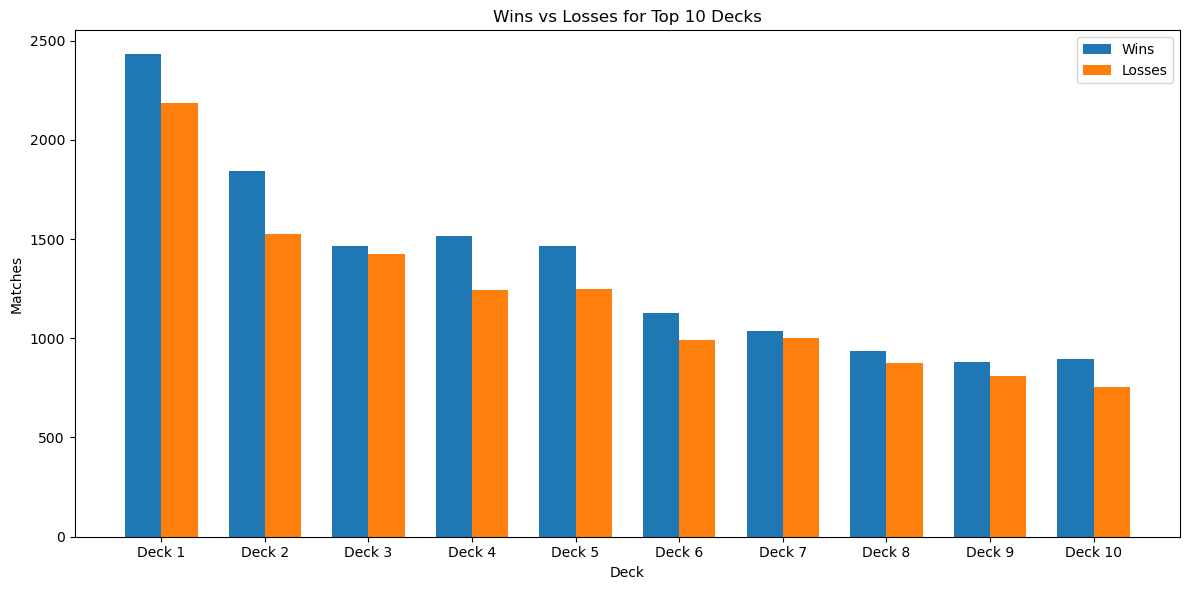

In [73]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(df_table))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, df_table["Wins"], width, label="Wins")
plt.bar(x + width/2, df_table["Losses"], width, label="Losses")

plt.xticks(x, df_table["Deck"])
plt.xlabel("Deck")
plt.ylabel("Matches")
plt.title("Wins vs Losses for Top 10 Decks")
plt.legend()

plt.tight_layout()  # 👈 prevents label cutoff
plt.show()

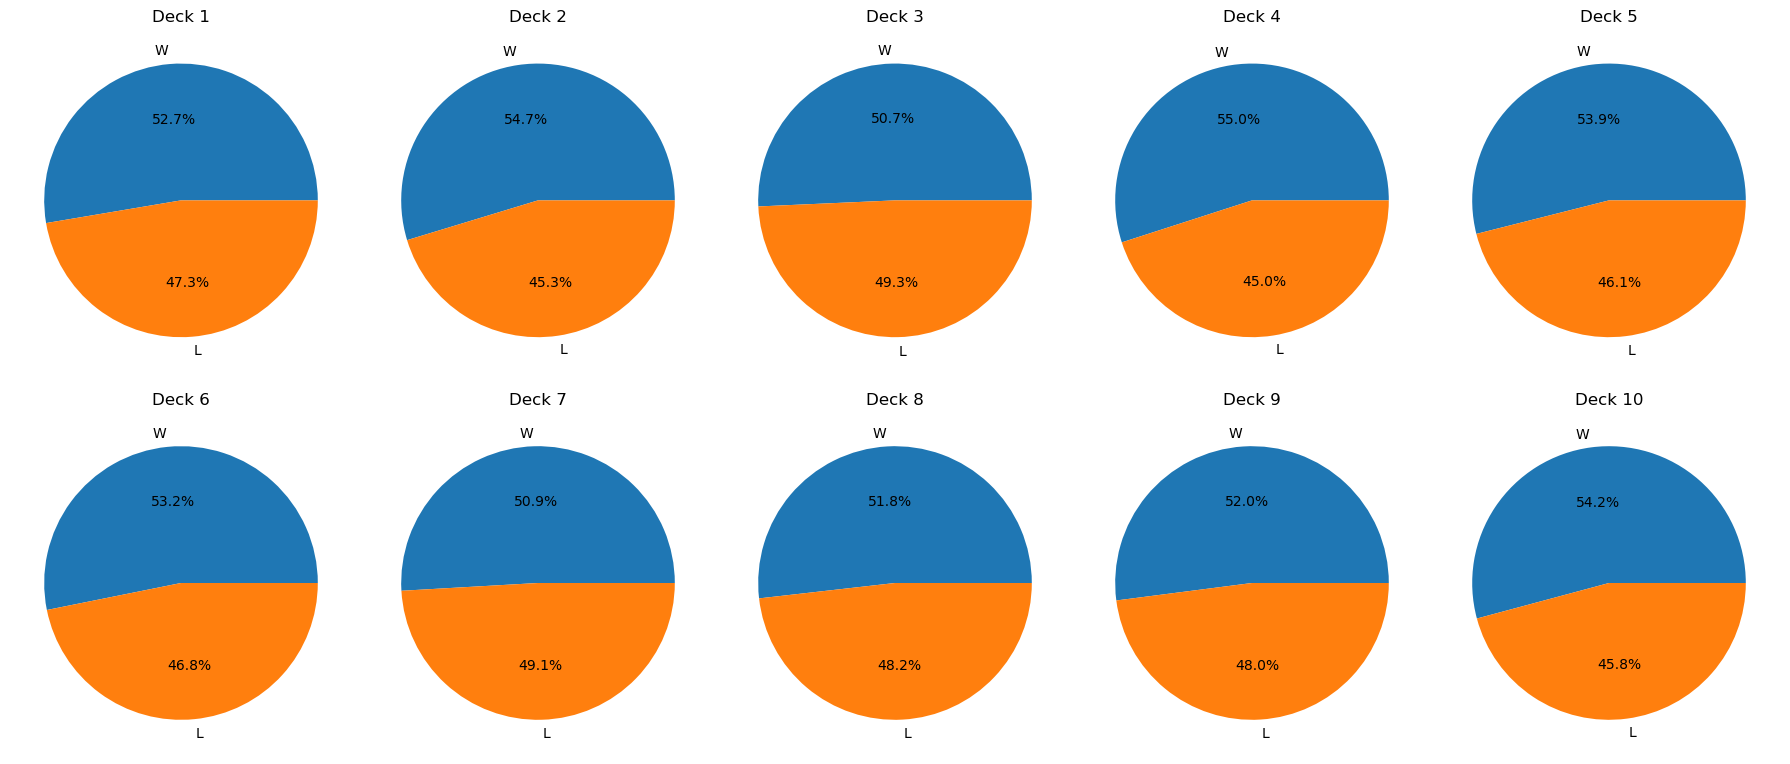

In [74]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, ax in enumerate(axes.flatten()):
    wins = df_table.loc[i, "Wins"]
    losses = df_table.loc[i, "Losses"]

    ax.pie(
        [wins, losses],
        labels=["W", "L"],
        autopct='%1.1f%%'
    )

    ax.set_title(df_table.loc[i, "Deck"])

plt.tight_layout()
plt.show()